# Identify CSTR-separator SS using PARSIM-K


In [89]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import matplotlib.pyplot as plt
import numpy as np
import sys
import joblib
from sklearn.preprocessing import StandardScaler

from sippy_unipi import system_identification
from sippy_unipi import functionsetSIM as fsetSIM

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
src_path = os.path.join(project_root, "src")
if src_path not in sys.path:
    sys.path.append(src_path)

import models
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading the identification dataset


In [90]:
# Plant used to generate ../data/cstr_separator_ident.npz
CSTR = models.CSTRSeparator()


In [91]:
# Load pre-generated CSTR-separator identification data
# Y: [T1, T2, T3, xB3], U: [Q1, Q2, Q3, F10, F20, Fr] (yield-paired steps, 180 s holds)
data = np.load("../data/cstr_separator_ident.npz", allow_pickle=True)
sim = {"Y": np.array(data["Y"], dtype=float), "U": np.array(data["U"], dtype=float)}
print("Loaded", data.files)
print("Y", sim["Y"].shape, list(data["y_names"]))
print("U", sim["U"].shape, list(data["u_names"]))
print("Ts =", float(data["Ts"]), "step_time =", int(data["step_time"]), "no_steps =", int(data["no_steps"]))


Loaded ['Y', 'Y_clean', 'U', 'X', 'U_plant', 'Ts', 'step_time', 'no_steps', 'y_names', 'u_names', 'x0', 'u_nom', 'mv_constraints', 'noise_frac', 'noise_sigma', 'noise_seed', 'n_train_noise']
Y (18000, 4) [np.str_('T1'), np.str_('T2'), np.str_('T3'), np.str_('xB3')]
U (18000, 6) [np.str_('Q1'), np.str_('Q2'), np.str_('Q3'), np.str_('F10'), np.str_('F20'), np.str_('Fr')]
Ts = 1.0 step_time = 180 no_steps = 100


In [92]:
# Measurement noise is already in Y (1% of train-range, stored in the npz).
if "noise_sigma" in data.files:
    print("Stored measurement noise (already in Y):")
    for name, s in zip(data["y_names"], np.array(data["noise_sigma"], dtype=float)):
        print(f"  {name}: sigma={s:.4g}")
    print("noise_frac =", float(data["noise_frac"]), "seed =", int(data["noise_seed"]))


Stored measurement noise (already in Y):
  T1: sigma=0.4939
  T2: sigma=0.5075
  T3: sigma=0.5558
  xB3: sigma=0.003263
noise_frac = 0.01 seed = 42


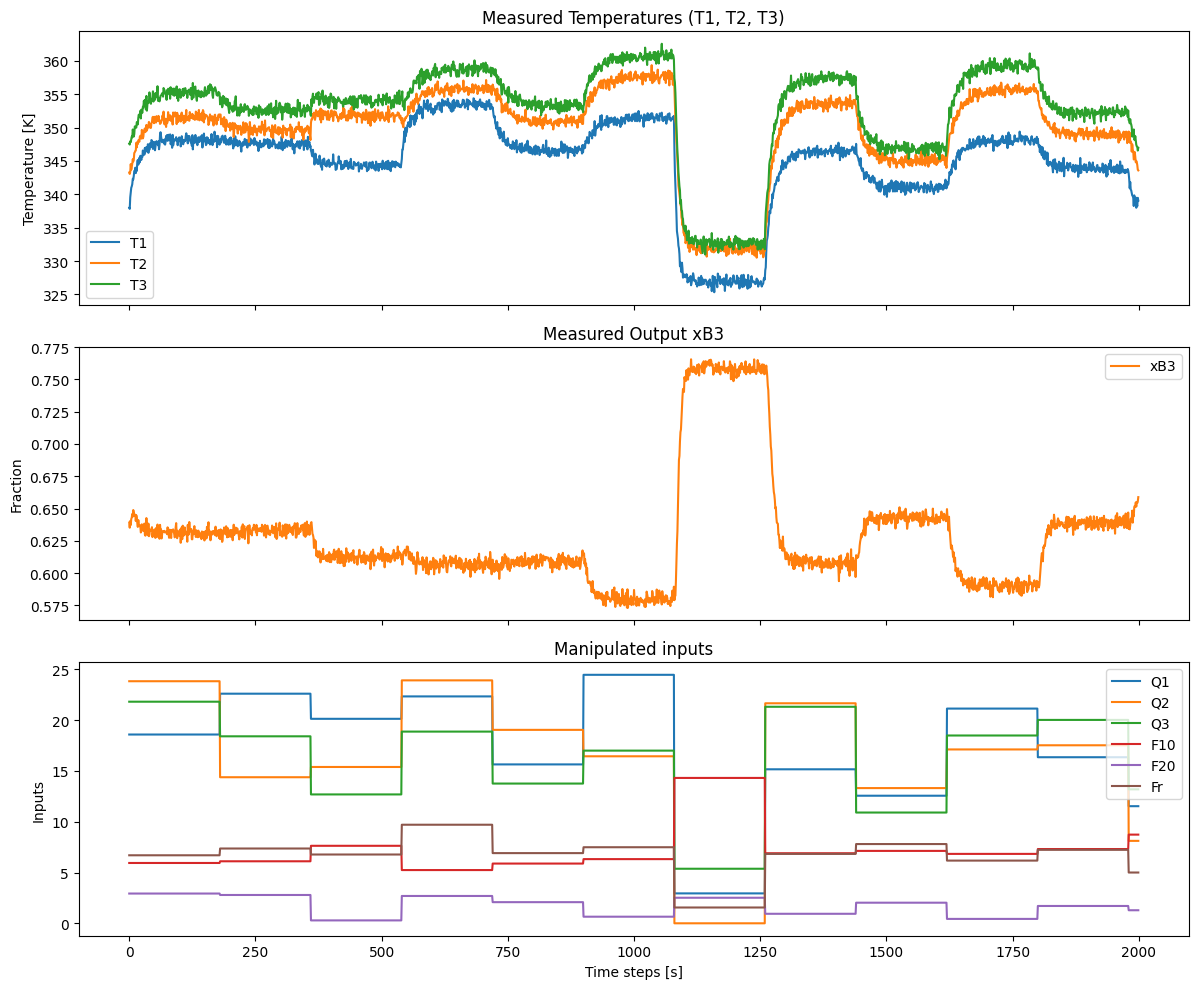

In [93]:
part = 2000
y_names = ["T1", "T2", "T3", "xB3"]
u_names = ["Q1", "Q2", "Q3", "F10", "F20", "Fr"]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot T1, T2, T3 together
for i, name in enumerate(y_names[:-1]):  # T1, T2, T3
    axes[0].plot(sim["Y"][:part, i], label=name)
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Measured Temperatures (T1, T2, T3)")
axes[0].legend()

# Plot xB3 separately
axes[1].plot(sim["Y"][:part, 3], label="xB3", color="tab:orange")
axes[1].set_ylabel("Fraction")
axes[1].set_title("Measured Output xB3")
axes[1].legend()

# Plot inputs
for i, name in enumerate(u_names):
    axes[2].plot(sim["U"][:part, i], label=name)
axes[2].set_xlabel("Time steps [s]")
axes[2].set_ylabel("Inputs")
axes[2].set_title("Manipulated inputs")
axes[2].legend()

plt.tight_layout()
plt.show()


In [94]:
# Fit scalers on the training split (same convention as Koopman notebooks)
n_train, n_dev = 12960, 2880
train_raw = {key: value[:n_train] for key, value in sim.items()}
dev_raw = {key: value[n_train:n_train + n_dev] for key, value in sim.items()}
test_raw = {key: value[n_train + n_dev:] for key, value in sim.items()}

scaler = StandardScaler()
scaler.fit(train_raw["Y"])
joblib.dump(scaler, "../data/scaler_cstr_separator.pkl")

scalerU = StandardScaler()
scalerU.fit(train_raw["U"])
joblib.dump(scalerU, "../data/scalerU_cstr_separator.pkl")


['../data/scalerU_cstr_separator.pkl']

In [95]:
train_sim = {
    "Y": scaler.transform(train_raw["Y"]),
    "U": scalerU.transform(train_raw["U"]),
}
dev_sim = {
    "Y": scaler.transform(dev_raw["Y"]),
    "U": scalerU.transform(dev_raw["U"]),
}
test_sim = {
    "Y": scaler.transform(test_raw["Y"]),
    "U": scalerU.transform(test_raw["U"]),
}
print("train", train_sim["Y"].shape, "dev", dev_sim["Y"].shape, "test", test_sim["Y"].shape)


train (12960, 4) dev (2880, 4) test (2160, 4)


## Identification using PARSIM-K


In [96]:
# SIPPY wants (n_signals, N). It auto-transposes, but be explicit.
y_tot = train_sim["Y"].T.copy()
U = train_sim["U"].T.copy()
print("y_tot", y_tot.shape, "U", U.shape)


y_tot (4, 12960) U (6, 12960)


In [97]:
import warnings
import sippy_unipi.functionsetSIM as _fset
import sippy_unipi.OLSims_methods as _olm

# NumPy 2.x emits false overflow warnings for 1-D `a @ a` (SIPPY Vn_mat).
def _Vn_mat_dot(y, yest):
    eps = np.asarray(y).reshape(-1) - np.asarray(yest).reshape(-1)
    return float(np.dot(eps, eps) / max(eps.size, 1))

_fset.Vn_mat = _Vn_mat_dot
_olm.Vn_mat = _Vn_mat_dot

U_test = test_sim["U"].T
Y_test = test_sim["Y"].T
order_results = []
sys_id = None
best_mae = np.inf

# Horizon must exceed the largest order (SIPPY default SS_f=20 would cap n at 20).
SS_f = 40
print(f"{'order':>5}  {'test MAE':>12}  {'test MSE':>12}  {'rho(A)':>10}")
for n in range(4, 21):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*encountered in matmul")
        ident = system_identification(
            y_tot.copy(),
            U.copy(),
            "N4SID",
            SS_fixed_order=int(n),
            SS_f=SS_f,
            SS_A_stability=True,
        )
    _, y_hat = fsetSIM.SS_lsim_process_form(
        ident.A, ident.B, ident.C, ident.D,
        U_test,
        np.linalg.pinv(ident.C) @ Y_test[:, :1],
    )
    err = Y_test - y_hat
    mae = float(np.mean(np.abs(err)))
    mse = float(np.mean(err ** 2))
    rho = float(np.max(np.abs(np.linalg.eigvals(ident.A))))
    order_results.append({"order": n, "mae": mae, "mse": mse, "rho": rho, "sys": ident})
    print(f"{n:5d}  {mae:12.6g}  {mse:12.6g}  {rho:10.5f}")
    if mae < best_mae:
        best_mae = mae
        sys_id = ident

print(f"best test MAE: order {sys_id.A.shape[0]}  MAE={best_mae:.6g}")


order      test MAE      test MSE      rho(A)
    4      0.362799      0.225091     0.98955
    5      0.321653      0.176545     0.99167
    6      0.306431      0.173505     0.99177
    7      0.307823      0.173551     0.99173
    8      0.308451      0.173678     0.99180
    9      0.307328      0.172502     0.99183
   10      0.305667      0.171692     0.99188
   11      0.306829      0.172092     0.99203
   12      0.307917      0.172842     0.99201
   13      0.304861      0.172711     0.99212
   14      0.305106      0.172757     0.99212
   15      0.305549      0.172864     0.99212
   16       0.30584      0.172959     0.99211
   17      0.305847      0.172939     0.99212
   18      0.305608      0.172418     0.99214
   19      0.305621      0.172551     0.99212
   20      0.306506      0.172407     0.99213
best test MAE: order 13  MAE=0.304861


In [98]:
ident = system_identification(
    y_tot.copy(),
    U.copy(),
    "N4SID",
    SS_fixed_order=int(n),
    SS_f=13,
    SS_A_stability=True,
)

Warning! The horizon must be larger than the model order, max_order setted as f


/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/patrik/miniconda3/envs/sippy/lib/python3.10/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


In [99]:
sys_id.A


array([[ 9.51115316e-01, -4.98134837e-02,  3.77462263e-03,
        -8.54049989e-03, -1.60763596e-02,  1.11705920e-02,
        -1.00187467e-02,  7.46656440e-03, -1.01656064e-02,
         1.82810183e-03,  8.06391758e-03, -2.97983663e-03,
         4.38885020e-03],
       [-8.69322430e-03,  9.82500500e-01, -1.83936745e-02,
        -2.27315923e-02, -3.23076157e-02,  2.27212770e-02,
         4.11894692e-02, -1.46749749e-02,  1.27015156e-02,
        -7.71292564e-04, -1.37971927e-02, -6.35004462e-03,
        -9.54992879e-03],
       [ 6.18039406e-03,  1.17448760e-02,  9.70102862e-01,
        -2.82920005e-02, -3.69595636e-02, -4.36851669e-02,
         2.58199810e-02,  3.70981824e-02,  3.57014686e-03,
         1.88546670e-02,  1.72734569e-02,  1.09279538e-02,
         1.82007600e-03],
       [ 2.79018011e-02,  3.05298746e-02,  9.91402521e-03,
         9.84483099e-01, -4.44174132e-02,  6.76120189e-03,
         3.54113721e-02,  3.02455887e-02,  1.36256098e-02,
         1.70359033e-02,  1.66577111e

In [100]:
append = "_cstr_separator_parsimK"
np.save("../data/A" + append + ".npy", sys_id.A)
np.save("../data/B" + append + ".npy", sys_id.B)
np.save("../data/C" + append + ".npy", sys_id.C)
np.save("../data/D" + append + ".npy", sys_id.D)


In [101]:
xid, yid = fsetSIM.SS_lsim_process_form(
    sys_id.A, sys_id.B, sys_id.C, sys_id.D,
    test_sim["U"].T,
    np.linalg.pinv(sys_id.C) @ test_sim["Y"][0].reshape(-1, 1),
)


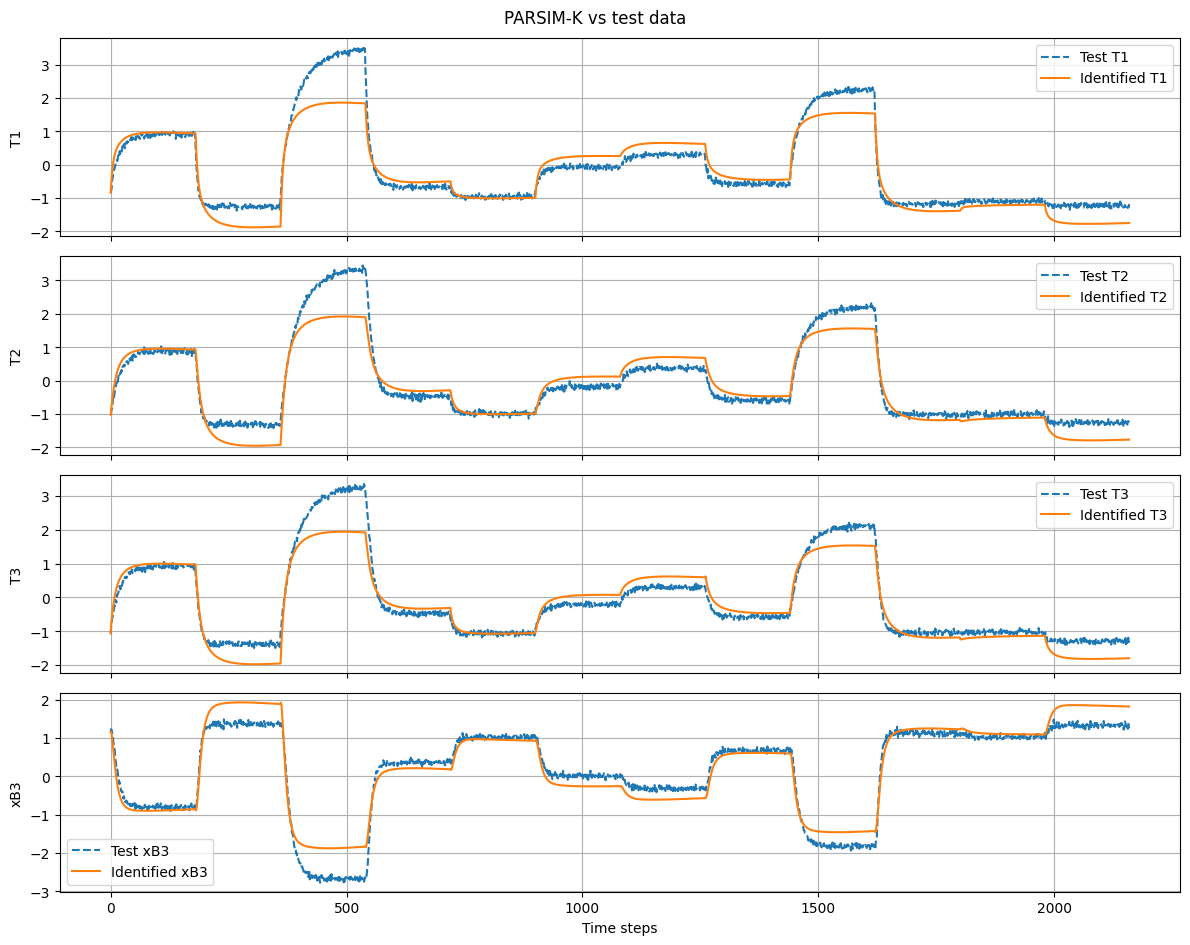

Test MAE per output: [0.34085885 0.3174209  0.29903745 0.26212789]
Sum of MAE: 1.2194450786478361


In [102]:
y_names = ["T1", "T2", "T3", "xB3"]
n_y = test_sim["Y"].shape[1]
fig, axes = plt.subplots(n_y, 1, figsize=(12, 2.4 * n_y), sharex=True)
if n_y == 1:
    axes = [axes]
for i, name in enumerate(y_names[:n_y]):
    axes[i].plot(test_sim["Y"][:, i], label=f"Test {name}", linestyle="--")
    axes[i].plot(yid[i, :], label=f"Identified {name}")
    axes[i].set_ylabel(name)
    axes[i].legend()
    axes[i].grid()
axes[-1].set_xlabel("Time steps")
fig.suptitle("PARSIM-K vs test data")
plt.tight_layout()
plt.show()

test_mae = np.mean(np.abs(test_sim["Y"].T - yid), axis=1)
print("Test MAE per output:", test_mae)
print("Sum of MAE:", np.sum(test_mae))


In [103]:
xid, yid = fsetSIM.SS_lsim_process_form(
    sys_id.A, sys_id.B, sys_id.C, sys_id.D,
    train_sim["U"].T,
    np.linalg.pinv(sys_id.C) @ train_sim["Y"][0].reshape(-1, 1),
)


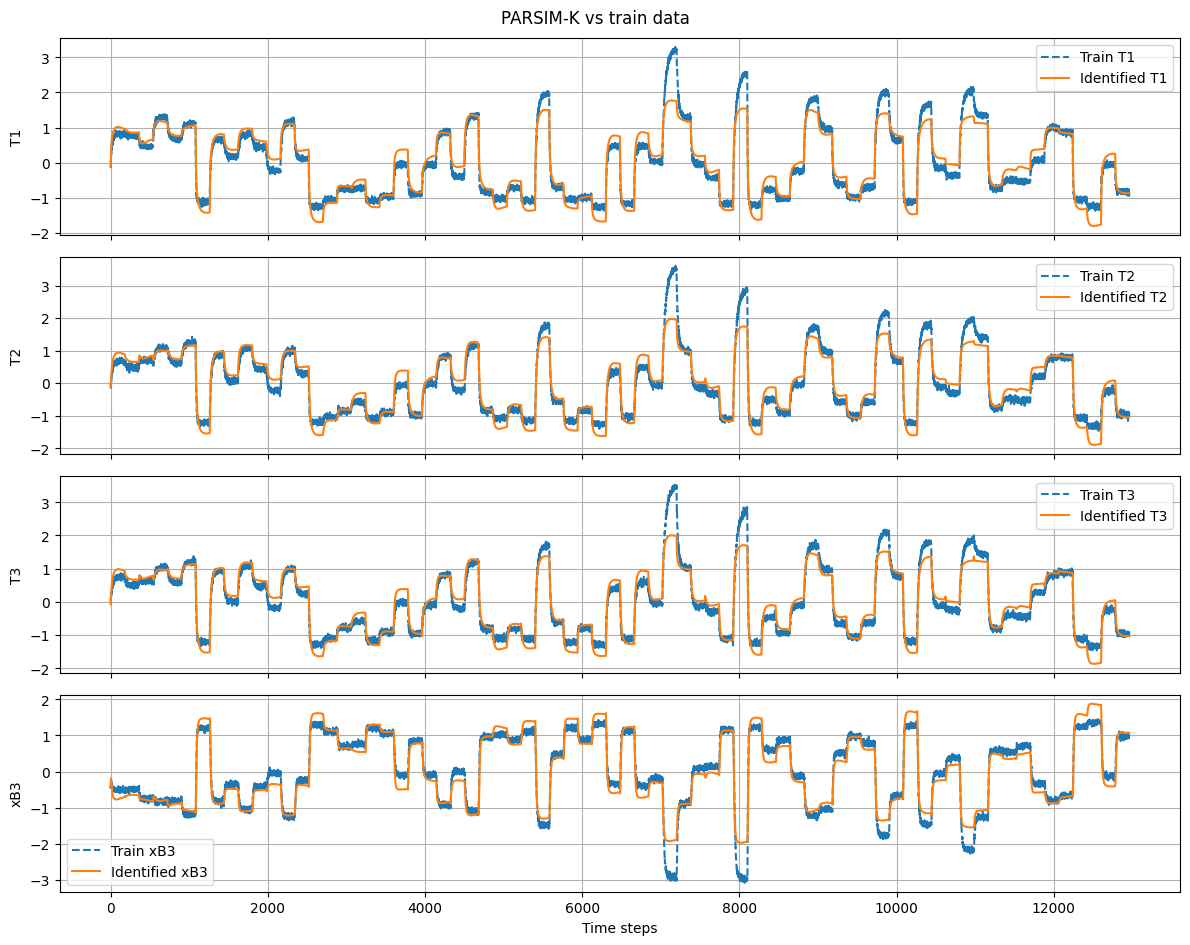

In [104]:
y_names = ["T1", "T2", "T3", "xB3"]
n_y = train_sim["Y"].shape[1]
fig, axes = plt.subplots(n_y, 1, figsize=(12, 2.4 * n_y), sharex=True)
if n_y == 1:
    axes = [axes]
for i, name in enumerate(y_names[:n_y]):
    axes[i].plot(train_sim["Y"][:, i], label=f"Train {name}", linestyle="--")
    axes[i].plot(yid[i, :], label=f"Identified {name}")
    axes[i].set_ylabel(name)
    axes[i].legend()
    axes[i].grid()
axes[-1].set_xlabel("Time steps")
fig.suptitle("PARSIM-K vs train data")
plt.tight_layout()
plt.show()
